# MODELING NOTEBOOK
DSO: Speed_Progression_Prediction

In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    accuracy_score
)

RANDOM_STATE = 42
df = pd.read_csv("C:/Users/marwe/Downloads/METABRIC_final_dataset111.csv", low_memory=False)
df.head()

,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,chemotherapy,cohort,er_status_measured_by_ihc,her2_status_measured_by_snp6,tumor_other_histologic_subtype,hormone_therapy,...,stmn2_mut,siah1_mut,age_category,triple_negative,menopausal_binary,risk_score,survival_category,aggressiveness_score,growth_rate,evolution_6m
0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,0.0,1.0,Positve,NEUTRAL,Ductal/NST,1.0,...,0,0,>70,0,1,14.4,>5ans,6.826534,0.925666,1
1,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,0.0,1.0,Positve,NEUTRAL,Ductal/NST,1.0,...,0,0,40-50,0,0,7.2,>5ans,4.876866,4.702194,0
2,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,1.0,1.0,Positve,NEUTRAL,Ductal/NST,1.0,...,0,0,40-50,0,0,9.8,>5ans,4.675041,1.691094,0
3,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,1.0,1.0,Positve,NEUTRAL,Mixed,1.0,...,0,0,40-50,0,0,15.8,>5ans,4.771393,3.255208,0
4,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,1.0,1.0,Positve,NEUTRAL,Mixed,1.0,...,0,0,>70,0,1,25.2,3-5ans,6.751078,1.622938,1


In [4]:
# Target variables
target_cols = [
    'aggressiveness_score',
    'growth_rate',
    'evolution_6m'
]

# Feature matrix
X = df.drop(columns=target_cols)

# Keep only numerical features
X = X.select_dtypes(include=[np.number])

# Target matrix (multi-output)
y = df[target_cols]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1904, 502)
y shape: (1904, 3)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y['evolution_6m']
)

print(f"Train : {X_train.shape[0]} patients ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]} patients ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nEvolution_6m distribution:")
print(f"Train : {y_train['evolution_6m'].value_counts(normalize=True).sort_index().values}")
print(f"Test  : {y_test['evolution_6m'].value_counts(normalize=True).sort_index().values}")


Train : 1523 patients (80.0%)
Test  : 381 patients (20.0%)

Evolution_6m distribution:
Train : [0.53972423 0.41103086 0.04924491]
Test  : [0.54068241 0.40944882 0.04986877]


In [6]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Standardization completed")
print(f"Train mean : {X_train_scaled.mean().mean():.4f} (≈ 0)")
print(f"Train std  : {X_train_scaled.std().mean():.4f} (≈ 1)")


Standardization completed
Train mean : 0.0000 (≈ 0)
Train std  : 1.0003 (≈ 1)


In [7]:
models = {
    'Random Forest': MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    'XGBoost': MultiOutputRegressor(
        XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE
        )
    )
}


In [8]:
results = {}

for name, model in models.items():
    print("\n" + "="*60)
    print(f"Model : {name}")
    print("="*60)

    # Training
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # --- Aggressiveness Score ---
    r2_aggr_train = r2_score(y_train.iloc[:, 0], y_train_pred[:, 0])
    r2_aggr_test = r2_score(y_test.iloc[:, 0], y_test_pred[:, 0])
    mae_aggr = mean_absolute_error(y_test.iloc[:, 0], y_test_pred[:, 0])

    # --- Growth Rate ---
    r2_growth_train = r2_score(y_train.iloc[:, 1], y_train_pred[:, 1])
    r2_growth_test = r2_score(y_test.iloc[:, 1], y_test_pred[:, 1])
    mae_growth = mean_absolute_error(y_test.iloc[:, 1], y_test_pred[:, 1])

    # --- Evolution 6M (derived classification) ---
    y_test_pred_class = (
        np.round(y_test_pred[:, 2])
        .astype(int)
        .clip(0, 2)
    )

    acc_test = accuracy_score(y_test.iloc[:, 2], y_test_pred_class)

    # Display results
    print("\nAggressiveness Score:")
    print(f"  R² train : {r2_aggr_train:.4f}")
    print(f"  R² test  : {r2_aggr_test:.4f}")
    print(f"  MAE test : {mae_aggr:.4f}")

    print("\nGrowth Rate:")
    print(f"  R² train : {r2_growth_train:.4f}")
    print(f"  R² test  : {r2_growth_test:.4f}")
    print(f"  MAE test : {mae_growth:.4f}")

    print("\nEvolution 6M:")
    print(f"  Accuracy : {acc_test:.4f} ({acc_test*100:.1f}%)")

    # Store results
    results[name] = {
        'model': model,
        'r2_aggr': r2_aggr_test,
        'r2_growth': r2_growth_test,
        'acc_evol': acc_test,
        'predictions': y_test_pred
    }



Model : Random Forest

Aggressiveness Score:
  R² train : 0.9880
  R² test  : 0.9260
  MAE test : 0.2056

Growth Rate:
  R² train : 0.9956
  R² test  : 0.9628
  MAE test : 0.7673

Evolution 6M:
  Accuracy : 0.9160 (91.6%)

Model : XGBoost

Aggressiveness Score:
  R² train : 0.9999
  R² test  : 0.9254
  MAE test : 0.2366

Growth Rate:
  R² train : 1.0000
  R² test  : 0.9654
  MAE test : 0.8334

Evolution 6M:
  Accuracy : 0.9108 (91.1%)


In [9]:
print("\n" + "="*60)
print("FINAL MODELING SUMMARY – DSO: Speed_Progression_Prediction")
print("="*60)

for name, res in results.items():
    print(f"\n{name}")
    print(f"  R² Aggressiveness : {res['r2_aggr']:.4f}")
    print(f"  R² Growth Rate    : {res['r2_growth']:.4f}")
    print(f"  Accuracy Evolution: {res['acc_evol']:.4f}")



FINAL MODELING SUMMARY – DSO: Speed_Progression_Prediction

Random Forest
  R² Aggressiveness : 0.9260
  R² Growth Rate    : 0.9628
  Accuracy Evolution: 0.9160

XGBoost
  R² Aggressiveness : 0.9254
  R² Growth Rate    : 0.9654
  Accuracy Evolution: 0.9108



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\marwe\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "c:\Users\marwe\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\marwe\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\marwe\AppData\Local\Programs\Python\Python312\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ^^^^^^^^^^^^^^^^^^^

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   -----------------

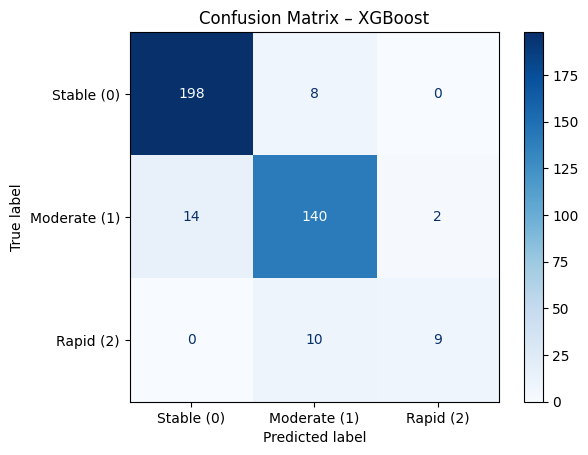

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(
    y_test.iloc[:, 2],
    y_test_pred_class,
    labels=[0, 1, 2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stable (0)', 'Moderate (1)', 'Rapid (2)']
)

disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix – {name}')
plt.grid(False)
plt.show()


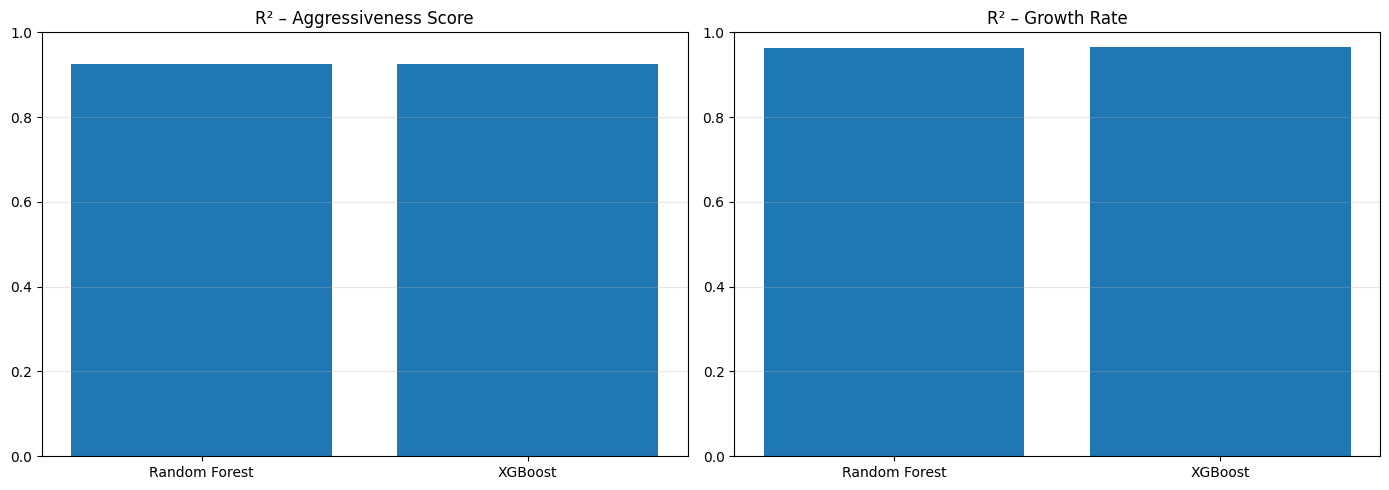

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Aggressiveness Score
axes[0].bar(
    results_df['Model'],
    results_df['R2_Aggressiveness']
)
axes[0].set_title('R² – Aggressiveness Score')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Growth Rate
axes[1].bar(
    results_df['Model'],
    results_df['R2_GrowthRate']
)
axes[1].set_title('R² – Growth Rate')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


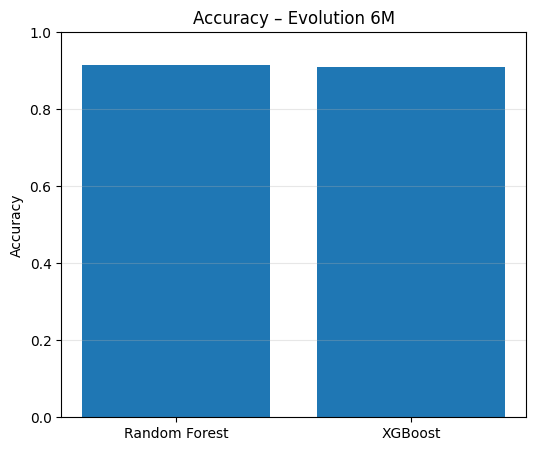

In [13]:
plt.figure(figsize=(6, 5))

plt.bar(
    results_df['Model'],
    results_df['Accuracy_Evolution6M']
)

plt.title('Accuracy – Evolution 6M')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()
